Buscar criar um histórico de linhas para cada veículo, ver se segue algum padrão ou é totalmente randômico.

In [1]:
import pandas as pd

In [2]:
veiculos = pd.read_csv('dados_geral/veiculo/veiculos_em_linha.csv')
registros_viagem = pd.read_csv('dados_geral/registros_viagem/viagem_informada.csv')

In [3]:
print(veiculos.info())
print(registros_viagem.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6598 entries, 0 to 6597
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   data                            6598 non-null   object 
 1   modo                            6598 non-null   object 
 2   id_veiculo                      6598 non-null   object 
 3   ano_fabricacao                  6598 non-null   int64  
 4   carroceria                      6598 non-null   object 
 5   data_ultima_vistoria            5854 non-null   object 
 6   id_carroceria                   6598 non-null   int64  
 7   id_chassi                       6598 non-null   int64  
 8   id_fabricante_chassi            6598 non-null   int64  
 9   id_interno_carroceria           6598 non-null   int64  
 10  id_planta                       6598 non-null   int64  
 11  indicador_ar_condicionado       6598 non-null   bool   
 12  indicador_elevador              65

Tratando os dados DOS REGISTROS: 

Buscando e lidando com valores nulos no route_id, no id_veiculo e no shape_id. Inconsistências em relação à outras tabelas vão sendo lidadas quando aparecerem.

In [4]:
linhas_route_na = registros_viagem["route_id"].isna()
#print(registros_viagem.loc[linhas_route_na,"id_veiculo"].isna())
linhas_veiculo_na = registros_viagem["id_veiculo"].isna()
#print(registros_viagem.loc[linhas_veiculo_na,"route_id"].isna().sum())
#print(linhas_route_na.sum())
#print(linhas_veiculo_na.sum())
#print(registros_viagem.loc[linhas_veiculo_na,:].head())
#print(registros_viagem.loc[linhas_route_na,:].head())

#Vendo se é possível completar os route_id com o "serviço", número da linha
#Serviço dos que não tem rota:
servicos = registros_viagem.loc[linhas_route_na,"servico"]
#Dos que tem rota nula, quantos tem serviço nulo?
print("Serviços \"nulos\" nas rotas nulas:",servicos.isna().sum())
#O resultado foi zero, então seria de grande valor tentar completar os route_id com o serviço
#Para isso, devo consultar uma outra tabela. Por enquanto, vamos jogar esses valores para fora e trabalhar com a tabela para ver o resultado.

#registros_viagem = registros_viagem.loc[~linhas_route_na,:]

registros_viagem = registros_viagem.loc[~linhas_veiculo_na,:]
print("Rotas \"nulas\":",linhas_route_na.sum())
print("Veiculos \"nulos\":",linhas_veiculo_na.sum())
print("Shapes \"nulos\":",registros_viagem["shape_id"].isna().sum())


Serviços "nulos" nas rotas nulas: 0
Rotas "nulas": 1003
Veiculos "nulos": 289
Shapes "nulos": 1857


Veículos nulos realmente não há o que possa ser feito.

Lidando com registros com ids de rotas vazios: GFTS-> Routes tem a relação ROUTEID e ROUTE SHORT NAME, que aparentemente é o "serviço" que está na tabela registros_viagem. 

Verificar se de fato é o mesmo serviço, e enriquecer, completando, se for o caso de ser. Vamos, portanto, cruzar dados com outra tabela.

In [5]:
rotas = pd.read_csv(r'dados_geral\gfts\gtfs\routes.csv')

Vendo se o servico e o route_short_name são a mesma coisa

In [6]:
servicos_cadastrados = set(rotas["route_short_name"].unique())
servicos_registrado = set(registros_viagem["servico"].unique())
registrados_sem_correspondecia = servicos_registrado - servicos_cadastrados
if (registrados_sem_correspondecia) != set():
    #mais preocupante
    print("Existem serviços nos registros de viagem que não estão presentes na tabela de rotas")
    print(len(registrados_sem_correspondecia))
#serviços na tabela de rotas que não estão presentes nos registros de viagem é
# ok o serviço apenas não foi efetuado.

#Dos que estão sem rota, quantos tem serviço que não dá match com a tabela de rotas? 
total_servicos_fora_rota = registros_viagem.loc[linhas_route_na,:]
total_servicos_fora_rota = total_servicos_fora_rota.loc[total_servicos_fora_rota["servico"].isin(registrados_sem_correspondecia),:].shape[0]
print("Apenas", total_servicos_fora_rota, " route_id nulos tem serviços que não estão presentes na tabela de rotas")


Existem serviços nos registros de viagem que não estão presentes na tabela de rotas
11
Apenas 2  route_id nulos tem serviços que não estão presentes na tabela de rotas


Dos 1003 registros sem route_id, apenas dois não tem serviço que dê match com o do mapa das rotas. Esses dois vão ser excluidos, o resto vai ser preenchido com o id_route da tabela GFTS

In [7]:
#verificar duplicatas para não dar problemas no merge
print(rotas["route_short_name"].duplicated().sum())

# se houver, apenas usar a primeira ocorrencia para evitar problemas de merge
rotas_unicas = rotas[['route_short_name', 'route_id']].drop_duplicates(subset='route_short_name')

36213


In [8]:
preencher = registros_viagem.loc[linhas_route_na,:]
preencher = preencher.loc[preencher["servico"].isin(registrados_sem_correspondecia),:]
#Agora, tenho que fazer o merge com a tabela de rotas para pegar o route_id
print(preencher.route_id.value_counts(dropna=False)) # Para confirmar que é o total
preencher.drop(columns=["route_id"], inplace=True) #tiro a coluna route_id, vai passar a ser a de rotas
indice_original = preencher.index
preencher = preencher.merge(
    rotas_unicas[['route_short_name', 'route_id']], 
    left_on="servico", 
    right_on="route_short_name", 
    how="left",
    suffixes=('', '_novo') 
# Mantém o original limpo e o vindo do merge com sufixo
)
preencher = preencher.drop(columns=['route_short_name'])
preencher.index = indice_original
#Faz com que as entradas com os índices iguais aos originais sejam atualizadas.
registros_viagem.update(preencher)


route_id
NaN    2
Name: count, dtype: int64


In [9]:
print(registros_viagem["route_id"].isna().sum())
print(total_servicos_fora_rota==registros_viagem["route_id"].isna().sum())
registros_viagem = registros_viagem.loc[~registros_viagem["route_id"].isna(),:]
print(registros_viagem["route_id"].isna().sum())

1003
False
0


Se True, preencheu certamente, e basta retirar os valores que sobraram, cujas rotas não permitiam preencher, se False, há problema na lógica.


Outro ponto de verificação, são os shapes das rotas: há valores nulos? Se há, tem como preencher?

In [10]:
print(registros_viagem["shape_id"].isna().sum())
print(len(registros_viagem["route_id"].unique()))
print(registros_viagem.shape[0])



1086
946
255433


Verificamos que alguns shapes (muito poucos) não estariam corretamente determinados. Mesmo assim tentar lidar com isso, vamos verificar se, para um route_id, os shape_id são iguais. Se forem, tranquilamente podemos preencher esses valores. Se não, vamos excluir esses dados. Caso sejam 2 valores de shape_id por rota com muita frequencia, dá pra inferir "ida e volta" e expandir um shape.


In [11]:
linhas = registros_viagem.groupby("route_id")["shape_id"].nunique()
print(linhas.loc[linhas>1].shape[0])
print(linhas.loc[linhas>2].shape[0])#Para testar se não era um simples caso de ida e volta

print(linhas.shape[0])


777
366
946


A conclusão anterior é que não é simples. Então, a solução será remover os shape_id nulos e considerar que uma rota pode ter múltiplos shapes: isso afeta a modelagem posterior, um veiculo vai ter varias rotas e varios shapes.

In [12]:
registros_viagem = registros_viagem.loc[~registros_viagem["shape_id"].isna(),:]
print(registros_viagem["shape_id"].isna().sum())

0


Agora, vamos entrar no momento de cruzamento de dados. Aqui, INCONSISTÊNCIAS terão que ser encontradas e tratadas.

Lidar com os dados dos veículos que aparecem nos registros de viagem, que são o que temos dados para trabalhar.

In [13]:
#ids únicos de veículos e ids unicos de veiculos usados em viagem
ids_em_linha = set(veiculos["id_veiculo"].unique())
ids_registros_viagem = set(registros_viagem["id_veiculo"].unique())

#ids que são veiculos cadastrados mas não aparecem nos registros de viagem, e vice-versa
fora_de_linha_nos_registros = ids_registros_viagem - ids_em_linha # todos que est
em_linha_fora_registros = ids_em_linha - ids_registros_viagem

if fora_de_linha_nos_registros:
    print(f"Há {len(fora_de_linha_nos_registros)} IDs 'fora de linha' presentes nos registros.")
    print(f"Exemplos: {list(fora_de_linha_nos_registros)[:5]}")
    print(len(ids_registros_viagem))
    print(len(ids_em_linha))
if em_linha_fora_registros:
    print(f"Há {len(em_linha_fora_registros)} IDs 'não usados' presentes em linha.")
    print(f"Exemplos: {list(em_linha_fora_registros)[:5]}")
total_fora_de_linha = registros_viagem[registros_viagem["id_veiculo"].isin(fora_de_linha_nos_registros)]

#Prints bobos para ter noção da corretude das funções de conjunto
#print(fora_de_linha_nos_registros.intersection(em_linha_fora_registros)==set())
#print(fora_de_linha_nos_registros.intersection(ids_em_linha)==set())
#print(fora_de_linha_nos_registros.intersection(ids_registros_viagem)==fora_de_linha_nos_registros)
#print(em_linha_fora_registros.intersection(ids_em_linha)==em_linha_fora_registros)


Há 486 IDs 'fora de linha' presentes nos registros.
Exemplos: ['C50042', 'A72146', 'B11640', 'D33254', 'C30045']
4848
6598
Há 2236 IDs 'não usados' presentes em linha.
Exemplos: ['C47808', 'E12743C', 'B10534', 'M901043', 'B63105']


A solução é simplificar, não há o que fazer com essas inconsistências. Estamos usando apenas a interseção para fazer o históricos. 

Além disso, para especializar nossa abordagem na questão do ar condicionado, vale simplificar a tabela de veículos em linha. O resto, da tabela de registros de viagem, vai ser mantido.

In [14]:
#"Veiculos" simplificado
veiculos_simplificado = veiculos.loc[:,['id_veiculo','indicador_ar_condicionado']]

Cruzar os dados do veículo com registros de viagem para começar a compreender as rotas e os shapes das rotas de cada veículo

In [15]:
#Join das tabelas
veiculos_em_linha_em_viagem = veiculos_simplificado.merge(
    registros_viagem, 
    on='id_veiculo', 
    how='inner',
    suffixes=('_veic', '_viag')
)
print(veiculos_em_linha_em_viagem.info())
print(veiculos_em_linha_em_viagem["route_id"].nunique())
#Teste: print((veiculos_em_linha_em_viagem.shape[0]+entradas_fora_de_linha.shape[0])==registros_viagem.shape[0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247806 entries, 0 to 247805
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id_veiculo                   247806 non-null  object 
 1   indicador_ar_condicionado    247806 non-null  bool   
 2   data                         247806 non-null  object 
 3   datetime_partida             247806 non-null  object 
 4   datetime_chegada             247806 non-null  object 
 5   datetime_processamento       247806 non-null  object 
 6   datetime_captura             247806 non-null  object 
 7   trip_id                      0 non-null       float64
 8   route_id                     247806 non-null  object 
 9   shape_id                     247806 non-null  object 
 10  servico                      247806 non-null  object 
 11  sentido                      247806 non-null  object 
 12  id_viagem                    247806 non-null  object 
 13 

In [16]:
#Par veiculo - rotas, e frequencia que aparece
contagem_rotas_shape = veiculos_em_linha_em_viagem.groupby(
    ['id_veiculo', 'indicador_ar_condicionado', 'route_id', 'shape_id']
    ).size().reset_index(name='frequencia')
#Ainda não normalizar para frequência relativa, isso será feito depois
print(contagem_rotas_shape.groupby('id_veiculo').size().shape)
print(contagem_rotas_shape.head())

(4362,)
  id_veiculo  indicador_ar_condicionado route_id shape_id  frequencia
0     A27501                       True      243      536           8
1     A27501                       True      243      537           5
2     A27501                       True      244      538           1
3     A27501                       True      246      541           1
4     A27501                       True      246      667           1


Agora, a ideia é trazer os dados de shape para dentro da tabela de contagem rotas shape, e depois fazer um mapa de id_veiculo para todos esses dados. Com isso, podemos analisar valores de ar condicionado.

Novamente, cruzaremos dados, e resolveremos inconsistências

In [17]:
shapes = pd.read_csv(r'dados_geral\gfts\gtfs\shapes_geom.csv')

In [18]:
print(shapes.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13946 entries, 0 to 13945
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   feed_version     13946 non-null  object 
 1   feed_start_date  13946 non-null  object 
 2   feed_end_date    13732 non-null  object 
 3   shape_id         13946 non-null  object 
 4   shape            13946 non-null  object 
 5   shape_distance   13946 non-null  float64
 6   start_pt         13946 non-null  object 
 7   end_pt           13946 non-null  object 
 8   versao_modelo    13946 non-null  object 
dtypes: float64(1), object(8)
memory usage: 980.7+ KB
None


Agora, verificar se há dados de shape para todo shape ID, e verificar

In [19]:
print(shapes["shape"].isna().sum())
#Normalizar para um tipo somente
contagem_rotas_shape["shape_id"] = contagem_rotas_shape["shape_id"].astype(str).str.strip()
shapes["shape_id"] = shapes["shape_id"].astype(str).str.strip()
#Pegar os shapes que estão nos registros de viagem e comparar com os shapes predeterminados
shapes_registro = set(contagem_rotas_shape["shape_id"].unique())
shapes_predeterminados = set(shapes["shape_id"].unique())
#shapes_registro_fora_predeterminados = shapes_registro - shapes_predeterminados
#shapes_predeterminados_fora_registro = shapes_predeterminados - shapes_registro
print(len(shapes_registro))
print(len(shapes_predeterminados))
print(len(shapes_registro & shapes_predeterminados))
shapes_em_comum = shapes_registro & shapes_predeterminados


0
2017
1914
1017


Isso é muito negativo. Perderíamos muitos valores de shape. Para lidar com isso, vamos tentar fazer uma "simplificação", de emprestar shapes, caso um dos shapes perdido seja da mesma rota de um outro conhecido.

In [20]:
#quais shapes dos registros de viagem estão presentes nos shapes predeterminados?
em_comum = contagem_rotas_shape['shape_id'].isin(shapes_predeterminados)
#dicionario que mapeia route_id para shape_id entre os que tem match, ordenando pela frequencia para pegar
#o mais frequente
mapeamento_em_comum_mais_frequente = (
    contagem_rotas_shape[em_comum]
    .sort_values('frequencia', ascending=False)
    .drop_duplicates(subset='route_id')
    .set_index('route_id')['shape_id']
    .to_dict()
)

In [21]:
def aplicar_transmissão(row):
    # Se o shape original já tem geometria, mantém
    if row['shape_id'] in shapes_predeterminados:
        return row['shape_id']
    
    # Se não tem, tenta buscar o shape mais comum daquela rota
    return mapeamento_em_comum_mais_frequente.get(row['route_id'], None)

# Aplicando a lógica
contagem_rotas_shape['shape_id_recuperado'] = contagem_rotas_shape.apply(aplicar_transmissão, axis=1)

# Verificação do ganho de dados
nulos_antes = contagem_rotas_shape['shape_id'].isin(shapes_predeterminados).sum()
nulos_depois = contagem_rotas_shape['shape_id_recuperado'].notna().sum()

print(f"Shapes não nulos antes: {nulos_antes}")
print(f"Shapes não nulos depois: {nulos_depois}")
print(f"Ganho de: {nulos_depois - nulos_antes} registros.")
#Faço ser o novo shape_id
contagem_rotas_shape['shape_id'] = contagem_rotas_shape['shape_id_recuperado']
contagem_rotas_shape.drop(columns=['shape_id_recuperado'], inplace=True)
#Os que continuam NA não tem o que fazer.
contagem_rotas_shape = contagem_rotas_shape.loc[~contagem_rotas_shape["shape_id"].isna(),:]


Shapes não nulos antes: 42566
Shapes não nulos depois: 57275
Ganho de: 14709 registros.


In [22]:
print(shapes["shape_id"].nunique() == shapes.shape[0])
#Há duplicatas de shape_id, 

False


Agora, já que enriquecemos os dados com os shapes o máximo que pudiamos, basta trazer o shape de fato para o contagem_rotas_shape.

In [23]:
dados_finais = contagem_rotas_shape.merge(
    shapes[['shape_id', 'shape']], #so queremos esses dois
    left_on='shape_id',#do contagem_rotas_shape
    right_on='shape_id',#chave do shapes, que sabemos agora que é tudo igual
    how='left',
    suffixes=('', '_ref')   #colisão se houver colunas com mesmo nome: sei que não tem.
)
# 2. Limpeza de colunas redundantes do merge
if 'shape_id_ref' in dados_finais.columns:
    dados_finais.drop(columns=['shape_id_ref'], inplace=True)
# 3. Verificação de integridade
print(f"Total de registros na contagem: {len(dados_finais)}")
print(f"Registros sem geometria: {dados_finais['shape'].isna().sum()}")

# Exemplo do resultado
dados_finais = dados_finais.drop_duplicates(subset=['id_veiculo', 'route_id', 'shape_id'])# possivelmente o shape_id tem múltiplas entradas
print(len(dados_finais) == contagem_rotas_shape[['id_veiculo', 'route_id', 'shape_id']].drop_duplicates().shape[0])
print(dados_finais.head())

Total de registros na contagem: 603796
Registros sem geometria: 0
True
   id_veiculo  indicador_ar_condicionado    route_id shape_id  frequencia  \
0      A27501                       True  O0163AAA0A     446r          23   
20     A27501                       True  O0432AAA0A     jsxt           1   
27     A27501                       True  O0432AAA0A     ua78           2   
42     A27501                       True  O0433AAA0A     8fzm           8   
55     A27501                       True  O0433AAA0A     zr3e           7   

                                                shape  
0   LINESTRING(-43.21146 -22.89948, -43.21207 -22....  
20  LINESTRING(-43.23112 -22.97908, -43.23159 -22....  
27  LINESTRING(-43.25116 -22.91629, -43.25127 -22....  
42  MULTILINESTRING((-43.186867 -22.966688, -43.18...  
55  MULTILINESTRING((-43.25116 -22.91629, -43.2512...  


Normalizando para a frequência relativa.

In [24]:
#Frequência relativa de cada par rota-shape em relação ao total de trips do veículo
dados_finais["frequencia_relativa"] = dados_finais['frequencia'] / dados_finais.groupby('id_veiculo')['frequencia'].transform('sum')
veiculos_dominantes = dados_finais[dados_finais['frequencia_relativa'] > 0.4]
print(veiculos_dominantes.shape)
print(dados_finais.shape[0])
print(dados_finais.groupby('id_veiculo').size().shape)
print(dados_finais.head())
#Ou seja, de 4240 veiculos, 355 tem rotas dominantes, e todas tem um shape válido ao mínimo

(1818, 7)
48268
(4240,)
   id_veiculo  indicador_ar_condicionado    route_id shape_id  frequencia  \
0      A27501                       True  O0163AAA0A     446r          23   
20     A27501                       True  O0432AAA0A     jsxt           1   
27     A27501                       True  O0432AAA0A     ua78           2   
42     A27501                       True  O0433AAA0A     8fzm           8   
55     A27501                       True  O0433AAA0A     zr3e           7   

                                                shape  frequencia_relativa  
0   LINESTRING(-43.21146 -22.89948, -43.21207 -22....             0.479167  
20  LINESTRING(-43.23112 -22.97908, -43.23159 -22....             0.020833  
27  LINESTRING(-43.25116 -22.91629, -43.25127 -22....             0.041667  
42  MULTILINESTRING((-43.186867 -22.966688, -43.18...             0.166667  
55  MULTILINESTRING((-43.25116 -22.91629, -43.2512...             0.145833  


Agora fazendo um mapeador id_veiculo-> todas as suas rotas, shape de cada rota, e frequencia de cada rota e de cada shape.

In [25]:
mapa_veiculos = (
    dados_finais.groupby('id_veiculo')
    .apply(lambda x: x[['route_id', 'shape', 'frequencia_relativa']].to_dict('records'))
    .to_dict()
)
#Assim, para cada id_veiculo, tenho uma lista de dicionarios com route_id, shape e frequencia_relativa.
#Permite que para cada id_veiculo, eu consiga todos os pares rota-shape com a frequencia
mapa_ar_condicionado = (
    dados_finais[['id_veiculo', 'indicador_ar_condicionado']]
    .drop_duplicates()
    .set_index('id_veiculo')['indicador_ar_condicionado']
    .to_dict()
)
#Apenas para poder pegar os valores de ar condicionado, dropa duplicatas pois tem muitos registros por id_veiculo, 
#pq também estou agrupando por route_id e shape_id 


C:\Users\nb1_l\AppData\Local\Temp\ipykernel_44008\1672556674.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x[['route_id', 'shape', 'frequencia_relativa']].to_dict('records'))


Todos os mapas necessários para trabalhar com a interseção com mapas de onda de calor estão prontos. Basta agora fornecer algumas informações para se ter uma noção, de antemão, do resultado

In [26]:
# Filtragem de veículos únicos para evitar viés por número de viagens
veiculos_unicos = dados_finais[['id_veiculo', 'indicador_ar_condicionado']].drop_duplicates()

# Cálculo das frequências absolutas
contagem_ar = veiculos_unicos['indicador_ar_condicionado'].value_counts()

# Cálculo da porcentagem
porcentagem_ar = (contagem_ar.get(True, 0) / len(veiculos_unicos)) * 100

print(f"Total de veículos únicos: {len(veiculos_unicos)}")
print(f"Veículos com ar-condicionado: {contagem_ar.get(True, 0)}")
print(f"Porcentagem de frota refrigerada: {porcentagem_ar:.2f}%")

Total de veículos únicos: 4240
Veículos com ar-condicionado: 3901
Porcentagem de frota refrigerada: 92.00%


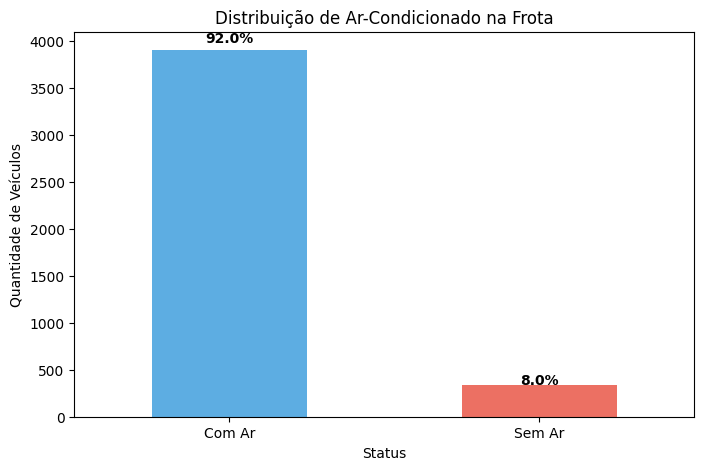

In [ ]:
ax = (veiculos_unicos['indicador_ar_condicionado']
      .value_counts()
      .rename(index={True: 'Com Ar', False: 'Sem Ar'})
      .plot(kind='bar', 
            color=['#5dade2', '#ec7063'], 
            figsize=(8, 5),
            rot=0))

ax.set_title('Distribuição de Ar-Condicionado na Frota')
ax.set_ylabel('Quantidade de Veículos')
ax.set_xlabel('Status')

total = len(veiculos_unicos)
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy() 
    ax.annotate(f'{(height/total)*100:.1f}%', 
                (x + width/2, y + height*1.02), 
                ha='center', fontweight='bold')

Testes de integridade: se os valores "se somam", buscar nas, ect

In [ ]:
print(mapa_veiculos["A27501"],mapa_ar_condicionado["A27501"])